<a href="https://colab.research.google.com/github/dkang1630/Conductor_Image_Classification/blob/main/ResNet_CORAL_Conductor_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Set up CUDA in OS
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
# Import libabries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import seaborn as sn
import pandas as pd
import torchvision
from torchvision import *
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
import torchvision.transforms as T
from torchvision import datasets, models, transforms
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score,  ConfusionMatrixDisplay
from google.colab import drive
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import random
import matplotlib.pyplot as plt
import time
import copy
import math

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

#Set random seed
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Torch random tensor:", torch.rand(3))  # Generate a random tensor with 3 elements
print("Numpy random array:", np.random.rand(3))  # Generate a random array with 3 elements
print("Python random number:", random.random())  # Generate a random float


Mounted at /content/drive
Torch random tensor: tensor([0.8823, 0.9150, 0.3829])
Numpy random array: [0.37454012 0.95071431 0.73199394]
Python random number: 0.6394267984578837


In [ ]:
# Custom dataset for ResNet (loads images as RGB)
class CustomDatasetResNet(Dataset):
    def __init__(self, base_path, classes, subfolders, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        self.class_map = {class_name: idx for idx, class_name in enumerate(classes)}

        for class_name in classes:
            class_path = os.path.join(base_path, class_name)
            if os.path.isdir(class_path):
                label = self.class_map[class_name]
                for subfolder in subfolders:
                    subfolder_path = os.path.join(class_path, subfolder)
                    if os.path.isdir(subfolder_path):
                        for img_name in os.listdir(subfolder_path):
                            img_path = os.path.join(subfolder_path, img_name)
                            self.data.append(img_path)
                            self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data[idx]
        label = self.labels[idx]
        # Convert image to RGB
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Function to split data
def split_data(base_path, classes, subfolders, train_ratio=0.8, random_state=123):
    dataset = CustomDatasetResNet(base_path, classes, subfolders, transform=None)
    images = dataset.data
    labels = dataset.labels
    X_train, X_test, y_train, y_test = train_test_split(
        images, labels, test_size=(1 - train_ratio), random_state=random_state, stratify=labels
    )
    return X_train, X_test, y_train, y_test

# Helper dataset class to load split data (also converting images to RGB)
class SplitDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Paths
BASE_PATH = "/content/drive/My Drive/Colab Notebooks/Conductor_Image_Detection/Images/Lab_experiment/Classified"
ORIGINAL_PATH = os.path.join(BASE_PATH, "Original")
GVN_PATH = os.path.join(BASE_PATH, "GVN_Processed")
CLASSES = ["Healthy", "Minor_Corrosion", "Corrosion_Pollutant_Build_Up", "Fretting_Pollutant_Build_Up_Corrosion"]
SUBFOLDERS = ["from_auto", "from_D", "from_H", "from_W"]
SAVE_PATH = "/content/drive/My Drive/Colab Notebooks/MDR_Inspection/best_coral_model.pth"

Using device: cuda


In [ ]:
# CORAL
def coral_extend_label(label: int, num_classes: int = 4):
    """
    Convert a single integer label into K - 1 binary indicators for CORAL.
    If label = 2 and num_classes=5 => [1,1,0,0].
    """
    bin_label = [1 if label > j else 0 for j in range(num_classes - 1)]
    return torch.tensor(bin_label, dtype=torch.float)

# Helper dataset class to load split data (also converting images to RGB) and returns bin_label
class SplitDatasetCORAL(Dataset):
    def __init__(self, image_paths, labels, transform=None, num_classes=4):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.num_classes = num_classes

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        bin_label = coral_extend_label(label, self.num_classes)
        return image, label, bin_label

#CORAL layer
class CORALLayer(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super(CORALLayer, self).__init__()
        self.num_classes = num_classes

        # Shared weight (1 weight vector for all tasks)
        self.weight = nn.Parameter(torch.Tensor(1, in_features)) #shape: [1,in_features]

        # Independent bias for each task
        self.biases = nn.Parameter(torch.Tensor(num_classes - 1)) #shape: [K-1]

        # Initialize parameters
        nn.init.kaiming_uniform_(self.weight, mode='fan_in', nonlinearity='relu')
        bound = 1 / math.sqrt(in_features)
        nn.init.uniform_(self.biases, -bound, bound)

    def forward(self, x):
        # Compute logits: (x * weight) + biases → [batch_size, K-1]
        return torch.matmul(x, self.weight.T) + self.biases

class CORALResNet50(nn.Module):
    def __init__(self, num_classes=4, dropout_rate=0.4):
        super(CORALResNet50, self).__init__()
        self.model = models.resnet50(pretrained=True)

        # Freeze all layers initially
        for param in self.model.parameters():
            param.requires_grad = False
        # Unfreeze the last block (layer4) for fine-tuning
        for param in self.model.layer4.parameters():
            param.requires_grad = True

        # Replace the original fully connected layer with a new one
        in_features = self.model.fc.in_features
        self.model.fc = nn.Identity() # Outputs features (2048-dim)

        # Add a dropout layer
        self.dropout = nn.Dropout(dropout_rate)
        #CORAL layer
        self.coral_layer = CORALLayer(in_features, num_classes)

    def forward(self, x):
        features = self.model(x)   #[batch_size, in_features]
        features = self.dropout(features)
        coral_outputs = self.coral_layer(features)  # [batch_size, K-1]
        return coral_outputs

def coral_loss_fn(logits, levels, imp):
    term1 = F.logsigmoid(logits) * levels
    term2 = (F.logsigmoid(logits) - logits) * (1 - levels) * imp  # Assuming `imp` is provided
    loss = -torch.mean(torch.sum(term1 + term2, dim=1))
    return loss

def train_evaluate_coral_model(model, train_loader, val_loader, criterion, device,
                               epochs=100, patience=10, lr=3e-4, early_stopping_threshold=0.05,
                               save_path=SAVE_PATH):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    best_val_loss = float('inf')
    epochs_no_improve = 0

    print("\nStarting Training & Evaluation...\n" + "="*50)
    for epoch in range(epochs):
        epoch_start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{epochs} ---")

        # --- Training Phase ---
        model.train()
        running_train_loss = 0.0
        running_train_corrects = 0
        total_train_samples = 0

        for batch_idx, (images, _, bin_labels) in enumerate(train_loader, start=1):
            images, bin_labels = images.to(device), bin_labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, bin_labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)
            preds = (outputs > 0).float()  # binary predictions for CORAL
            running_train_corrects += torch.sum(preds == bin_labels).item()
            total_train_samples += bin_labels.numel()

            if batch_idx % 10 == 0 or batch_idx == len(train_loader):
                print(f"[Train] Batch {batch_idx}/{len(train_loader)} processed.")

        train_loss = running_train_loss / total_train_samples
        train_accuracy = running_train_corrects / total_train_samples * 100

        # --- Evaluation Phase ---
        model.eval()
        running_val_loss = 0.0
        running_val_corrects = 0
        total_val_samples = 0
        all_true_labels = []
        all_predicted_labels = []

        for batch_idx, (images, labels, bin_labels) in enumerate(val_loader, start=1):
            images, labels, bin_labels = images.to(device), labels.to(device), bin_labels.to(device)
            with torch.no_grad():
                outputs = model(images)
                loss = criterion(outputs, bin_labels)
            running_val_loss += loss.item() * images.size(0)
            preds = (outputs > 0).float()  # binary predictions for CORAL
            running_val_corrects += torch.sum(preds == bin_labels).item()
            total_val_samples += bin_labels.numel()

            # For detailed metrics: CORAL ordinal prediction = count of thresholds > 0
            predicted_classes = (outputs > 0).sum(dim=1)
            all_predicted_labels.extend(predicted_classes.cpu().numpy())
            all_true_labels.extend(labels.cpu().numpy())

            if batch_idx % 10 == 0 or batch_idx == len(val_loader):
                print(f"[Validation] Batch {batch_idx}/{len(val_loader)} processed.")

        val_loss = running_val_loss / total_val_samples
        val_accuracy = running_val_corrects / total_val_samples * 100

        # Compute additional metrics on ordinal predictions
        ordinal_accuracy = accuracy_score(all_true_labels, all_predicted_labels) * 100
        precision = precision_score(all_true_labels, all_predicted_labels, average='macro')
        recall = recall_score(all_true_labels, all_predicted_labels, average='macro')
        f1 = f1_score(all_true_labels, all_predicted_labels, average='macro')
        conf_matrix = confusion_matrix(all_true_labels, all_predicted_labels)

        # Compute the loss gap: relative difference between val and train loss
        loss_gap = (val_loss - train_loss) / (train_loss + 1e-7)

        epoch_time = time.time() - epoch_start_time
        print(f"\nEpoch {epoch+1} Summary:")
        print(f"  - Time elapsed: {epoch_time:.2f} sec")
        print(f"  - Train Loss: {train_loss:.6f}, Train Acc: {train_accuracy:.2f}%")
        print(f"  - Val Loss: {val_loss:.6f}, Val Acc: {val_accuracy:.2f}%")
        print(f"  - Loss Gap (Val-Train)/Train: {loss_gap*100:.2f}%")
        print(f"  - Ordinal Accuracy: {ordinal_accuracy:.2f}%")
        print(f"  - Precision (macro): {precision:.4f}")
        print(f"  - Recall (macro): {recall:.4f}")
        print(f"  - F1 Score (macro): {f1:.4f}")

        # Save model if validation loss improves
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
            print("  -> Validation loss improved; model saved!")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
            if epochs_no_improve >= patience:
                print("  -> Early stopping triggered!")
                break

        scheduler.step(val_loss)

        # Optionally, display confusion matrix for current epoch
        disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=CLASSES)
        disp.plot(cmap='Blues')
        plt.title(f"Epoch {epoch+1} Confusion Matrix")
        plt.show()

    # Load the best model before returning
    model.load_state_dict(torch.load(save_path))
    print("\nBest model loaded for final evaluation.")
    return model

In [ ]:
IMG_SIZE = 224  # ResNet requires 224x224 input size
transform_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),               # Horizontal Flip (50% chance)
    transforms.RandomRotation(15),                        # Random Rotation (±15 degrees)
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random Translation (10% shift)
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Color Jitter
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)), # Random Crop with Scaling
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# Split datasets using your specified paths
X_train_original, X_test_original, y_train_original, y_test_original = split_data(ORIGINAL_PATH, CLASSES, SUBFOLDERS)
X_train_gvn, X_test_gvn, y_train_gvn, y_test_gvn = split_data(GVN_PATH, CLASSES, SUBFOLDERS)

# Function to print class distribution
def print_class_distribution(y_data, classes):
    distribution = np.bincount(y_data, minlength=len(classes))
    for i, count in enumerate(distribution):
        print(f"Class '{classes[i]}': {count}")

# Display the distributions for Original Dataset
print(f"Original Training data size: {len(X_train_original)}")
print(f"Original Test data size: {len(X_test_original)}")
print("\nOriginal Training labels distribution:")
print_class_distribution(y_train_original, CLASSES)
print("\nOriginal Test labels distribution:")
print_class_distribution(y_test_original, CLASSES)

# Display the distributions for GVN Dataset
print(f"\nGVN Training data size: {len(X_train_gvn)}")
print(f"GVN Test data size: {len(X_test_gvn)}")
print("\nGVN Training labels distribution:")
print_class_distribution(y_train_gvn, CLASSES)
print("\nGVN Test labels distribution:")
print_class_distribution(y_test_gvn, CLASSES)

# # Convert split data into torch datasets (apply the transform here)
# train_dataset_original = SplitDataset(X_train_original, y_train_original, transform=transform_resnet)
# test_dataset_original = SplitDataset(X_test_original, y_test_original, transform=transform_resnet)
# train_dataset_gvn = SplitDataset(X_train_gvn, y_train_gvn, transform=transform_resnet)
# test_dataset_gvn = SplitDataset(X_test_gvn, y_test_gvn, transform=transform_resnet)

# Create CORAL-friendly datasets
train_dataset_original = SplitDatasetCORAL(
    X_train_original, y_train_original, transform=transform_resnet, num_classes=len(CLASSES)
    )
test_dataset_original = SplitDatasetCORAL(
    X_test_original, y_test_original, transform=transform_val, num_classes=len(CLASSES)
    )

train_dataset_gvn = SplitDatasetCORAL(
    X_train_gvn, y_train_gvn, transform=transform_resnet, num_classes=len(CLASSES)
    )
test_dataset_gvn = SplitDatasetCORAL(
    X_test_gvn, y_test_gvn, transform=transform_val, num_classes=len(CLASSES)
    )

# DataLoader for training and testing Original Dataset
train_loader_original = DataLoader(train_dataset_original, batch_size=32, shuffle=True)
test_loader_original = DataLoader(test_dataset_original, batch_size=32, shuffle=False)

# DataLoader for training and testing GVN Dataset
train_loader_gvn = DataLoader(train_dataset_gvn, batch_size=32, shuffle=True)
test_loader_gvn = DataLoader(test_dataset_gvn, batch_size=32, shuffle=False)

Original Training data size: 3836
Original Test data size: 960

Original Training labels distribution:
Class 'Healthy': 1150
Class 'Minor_Corrosion': 286
Class 'Corrosion_Pollutant_Build_Up': 1278
Class 'Fretting_Pollutant_Build_Up_Corrosion': 1122

Original Test labels distribution:
Class 'Healthy': 288
Class 'Minor_Corrosion': 72
Class 'Corrosion_Pollutant_Build_Up': 320
Class 'Fretting_Pollutant_Build_Up_Corrosion': 280

GVN Training data size: 1652
GVN Test data size: 414

GVN Training labels distribution:
Class 'Healthy': 125
Class 'Minor_Corrosion': 222
Class 'Corrosion_Pollutant_Build_Up': 828
Class 'Fretting_Pollutant_Build_Up_Corrosion': 477

GVN Test labels distribution:
Class 'Healthy': 31
Class 'Minor_Corrosion': 56
Class 'Corrosion_Pollutant_Build_Up': 207
Class 'Fretting_Pollutant_Build_Up_Corrosion': 120


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 135MB/s]



Starting Training & Evaluation...

--- Epoch 1/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 1 Summary:
  - Time elapsed: 3711.81 sec
  - Train Loss: 0.120212, Train Acc: 82.60%
  - Val Loss: 0.104464, Val Acc: 84.72%
  - Loss Gap (Val-Train)/Train: -13.10%
  - Ordinal Accuracy: 60.00%
  - Precision (macro): 0.7472
  - Recall (macro): 0.5089
  - F1 Score (macro): 0.4091
  -> Validation loss improved; model saved!


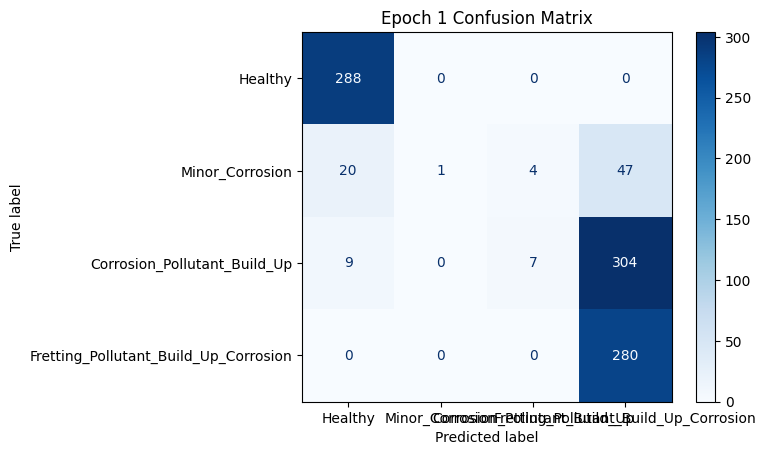


--- Epoch 2/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 2 Summary:
  - Time elapsed: 76.09 sec
  - Train Loss: 0.107589, Train Acc: 84.12%
  - Val Loss: 0.102760, Val Acc: 85.14%
  - Loss Gap (Val-Train)/Train: -4.49%
  - Ordinal Accuracy: 62.29%
  - Precision (macro): 0.5265
  - Recall (macro): 0.5229
  - F1 Score (macro): 0.4330
  -> Validation loss improved; model saved!


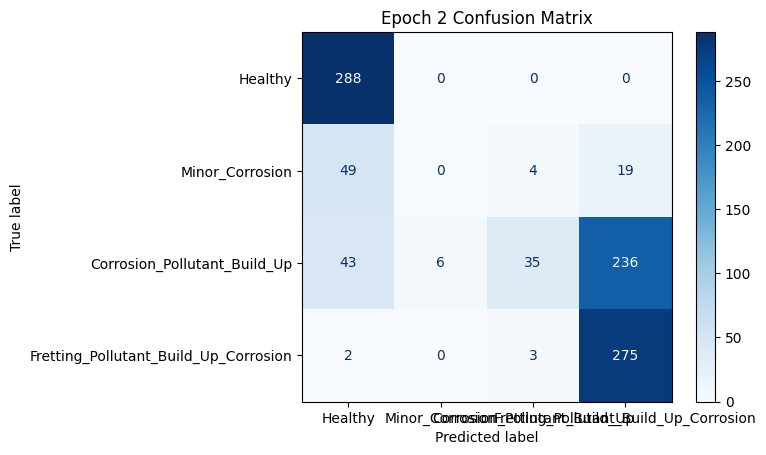


--- Epoch 3/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 3 Summary:
  - Time elapsed: 75.51 sec
  - Train Loss: 0.105763, Train Acc: 84.55%
  - Val Loss: 0.098936, Val Acc: 84.83%
  - Loss Gap (Val-Train)/Train: -6.46%
  - Ordinal Accuracy: 59.69%
  - Precision (macro): 0.6592
  - Recall (macro): 0.5093
  - F1 Score (macro): 0.4111
  -> Validation loss improved; model saved!


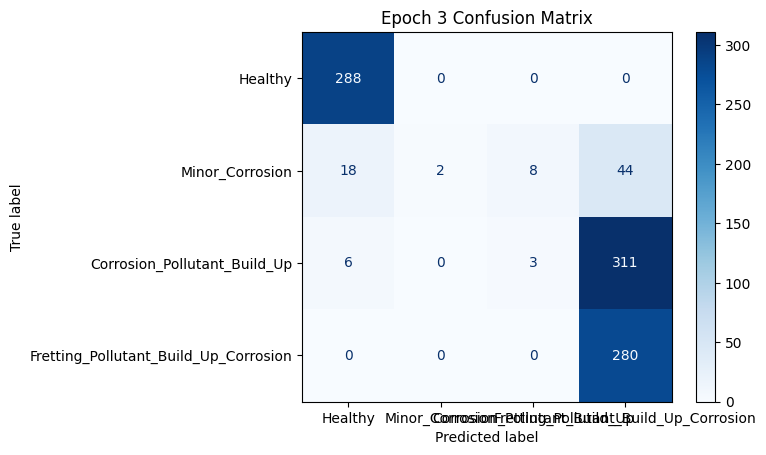


--- Epoch 4/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 4 Summary:
  - Time elapsed: 75.88 sec
  - Train Loss: 0.099364, Train Acc: 85.01%
  - Val Loss: 0.096250, Val Acc: 85.62%
  - Loss Gap (Val-Train)/Train: -3.13%
  - Ordinal Accuracy: 60.52%
  - Precision (macro): 0.6948
  - Recall (macro): 0.5125
  - F1 Score (macro): 0.4253
  -> Validation loss improved; model saved!


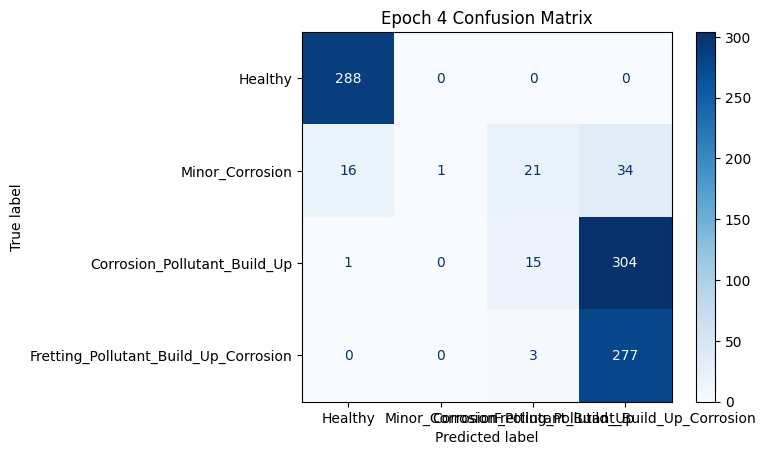


--- Epoch 5/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 5 Summary:
  - Time elapsed: 75.75 sec
  - Train Loss: 0.099059, Train Acc: 85.11%
  - Val Loss: 0.093616, Val Acc: 85.90%
  - Loss Gap (Val-Train)/Train: -5.49%
  - Ordinal Accuracy: 61.04%
  - Precision (macro): 0.6953
  - Recall (macro): 0.5299
  - F1 Score (macro): 0.4586
  -> Validation loss improved; model saved!


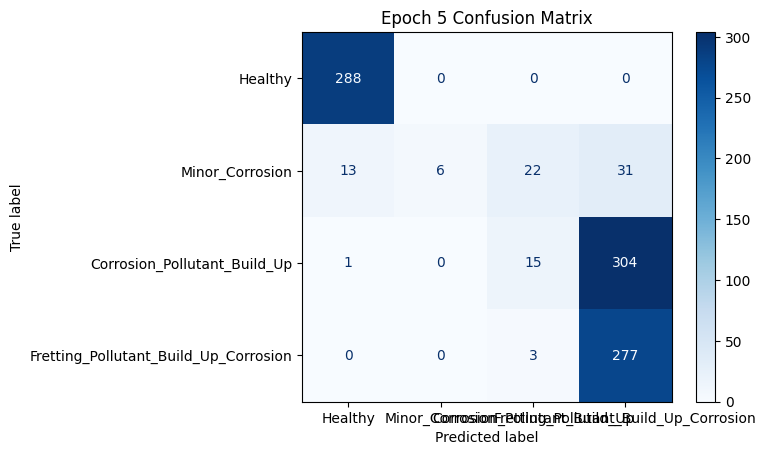


--- Epoch 6/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 6 Summary:
  - Time elapsed: 75.67 sec
  - Train Loss: 0.097270, Train Acc: 85.70%
  - Val Loss: 0.093832, Val Acc: 87.53%
  - Loss Gap (Val-Train)/Train: -3.53%
  - Ordinal Accuracy: 65.21%
  - Precision (macro): 0.7007
  - Recall (macro): 0.5640
  - F1 Score (macro): 0.5122
  -> No improvement for 1 epoch(s).


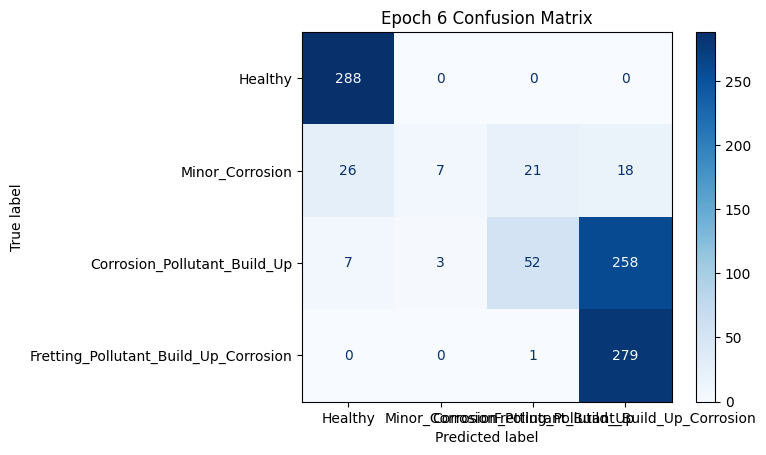


--- Epoch 7/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 7 Summary:
  - Time elapsed: 74.40 sec
  - Train Loss: 0.094501, Train Acc: 85.80%
  - Val Loss: 0.091513, Val Acc: 85.35%
  - Loss Gap (Val-Train)/Train: -3.16%
  - Ordinal Accuracy: 60.52%
  - Precision (macro): 0.6811
  - Recall (macro): 0.5182
  - F1 Score (macro): 0.4370
  -> Validation loss improved; model saved!


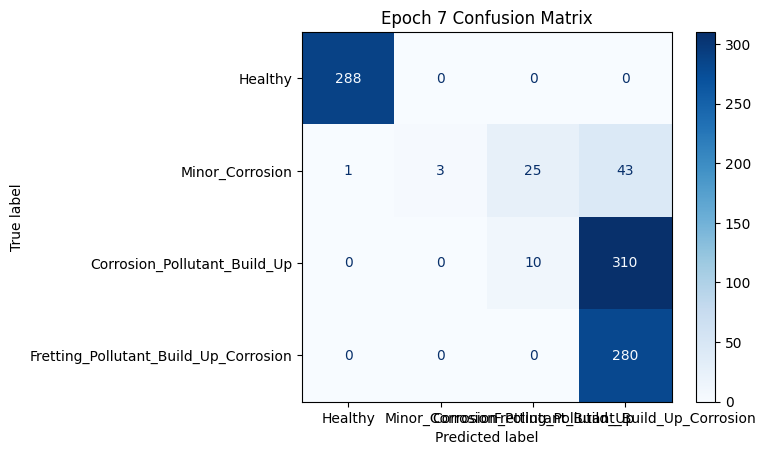


--- Epoch 8/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 8 Summary:
  - Time elapsed: 76.53 sec
  - Train Loss: 0.091949, Train Acc: 86.38%
  - Val Loss: 0.089927, Val Acc: 86.11%
  - Loss Gap (Val-Train)/Train: -2.20%
  - Ordinal Accuracy: 61.67%
  - Precision (macro): 0.6811
  - Recall (macro): 0.5321
  - F1 Score (macro): 0.4584
  -> Validation loss improved; model saved!


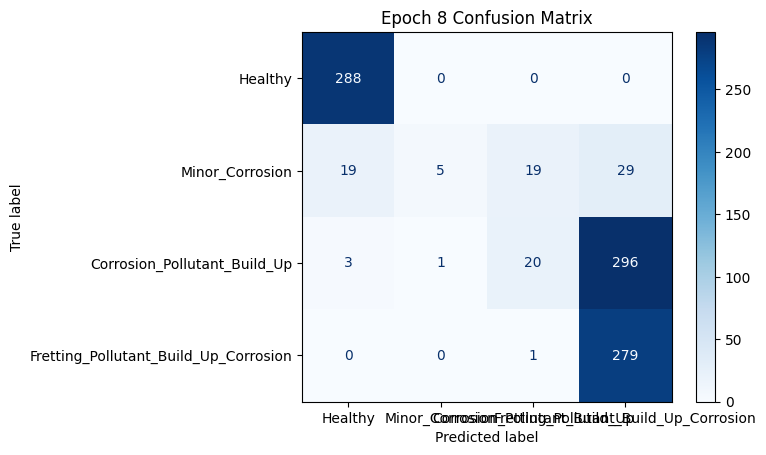


--- Epoch 9/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 9 Summary:
  - Time elapsed: 75.56 sec
  - Train Loss: 0.090188, Train Acc: 86.79%
  - Val Loss: 0.087759, Val Acc: 85.97%
  - Loss Gap (Val-Train)/Train: -2.69%
  - Ordinal Accuracy: 61.56%
  - Precision (macro): 0.7206
  - Recall (macro): 0.5234
  - F1 Score (macro): 0.4405
  -> Validation loss improved; model saved!


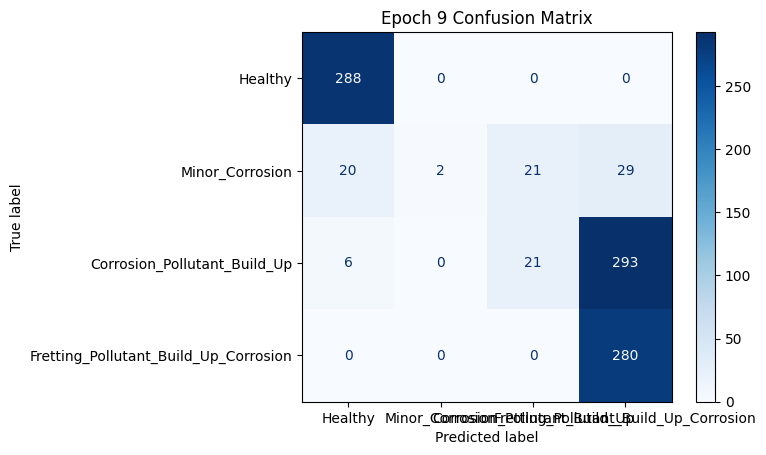


--- Epoch 10/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 10 Summary:
  - Time elapsed: 75.96 sec
  - Train Loss: 0.090432, Train Acc: 87.10%
  - Val Loss: 0.087632, Val Acc: 88.44%
  - Loss Gap (Val-Train)/Train: -3.10%
  - Ordinal Accuracy: 66.56%
  - Precision (macro): 0.7635
  - Recall (macro): 0.5630
  - F1 Score (macro): 0.5152
  -> Validation loss improved; model saved!


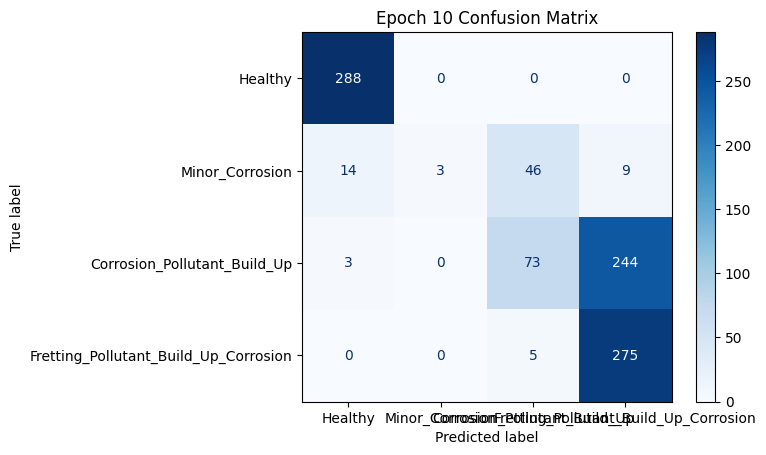


--- Epoch 11/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 11 Summary:
  - Time elapsed: 76.28 sec
  - Train Loss: 0.087666, Train Acc: 87.63%
  - Val Loss: 0.085640, Val Acc: 86.28%
  - Loss Gap (Val-Train)/Train: -2.31%
  - Ordinal Accuracy: 62.40%
  - Precision (macro): 0.4995
  - Recall (macro): 0.5239
  - F1 Score (macro): 0.4420
  -> Validation loss improved; model saved!


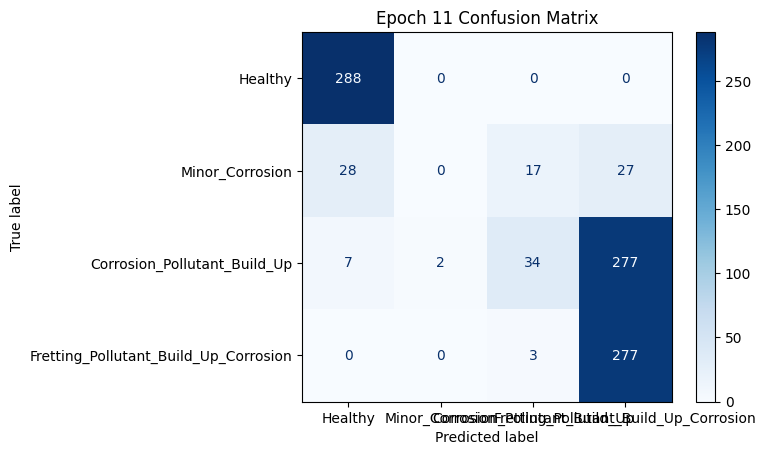


--- Epoch 12/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 12 Summary:
  - Time elapsed: 76.02 sec
  - Train Loss: 0.086450, Train Acc: 87.92%
  - Val Loss: 0.084044, Val Acc: 87.64%
  - Loss Gap (Val-Train)/Train: -2.78%
  - Ordinal Accuracy: 65.00%
  - Precision (macro): 0.6343
  - Recall (macro): 0.5514
  - F1 Score (macro): 0.4951
  -> Validation loss improved; model saved!


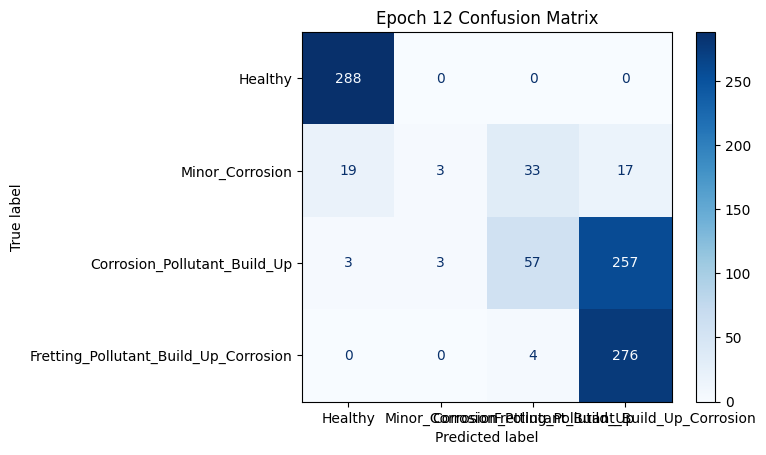


--- Epoch 13/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 13 Summary:
  - Time elapsed: 75.67 sec
  - Train Loss: 0.084590, Train Acc: 88.29%
  - Val Loss: 0.085183, Val Acc: 86.84%
  - Loss Gap (Val-Train)/Train: 0.70%
  - Ordinal Accuracy: 63.54%
  - Precision (macro): 0.7428
  - Recall (macro): 0.5456
  - F1 Score (macro): 0.4940
  -> No improvement for 1 epoch(s).


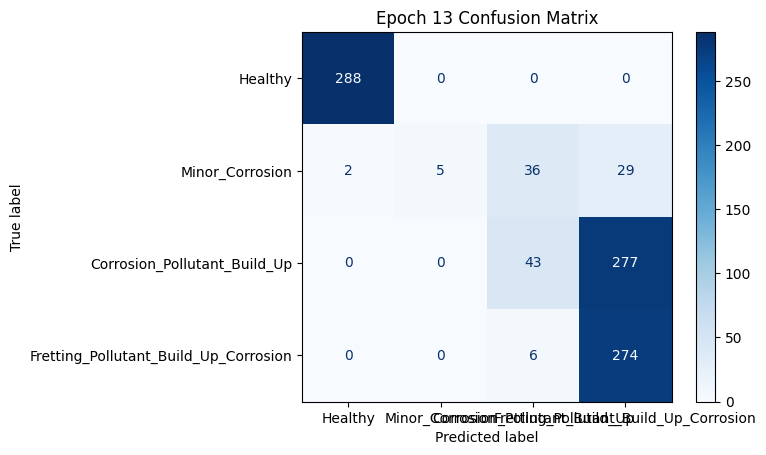


--- Epoch 14/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 14 Summary:
  - Time elapsed: 75.74 sec
  - Train Loss: 0.084702, Train Acc: 88.36%
  - Val Loss: 0.080860, Val Acc: 88.72%
  - Loss Gap (Val-Train)/Train: -4.54%
  - Ordinal Accuracy: 67.71%
  - Precision (macro): 0.7211
  - Recall (macro): 0.5799
  - F1 Score (macro): 0.5427
  -> Validation loss improved; model saved!


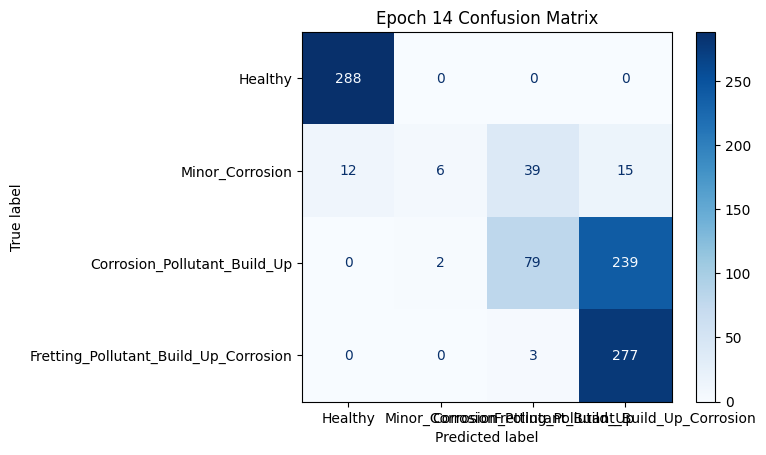


--- Epoch 15/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 15 Summary:
  - Time elapsed: 75.08 sec
  - Train Loss: 0.082328, Train Acc: 88.93%
  - Val Loss: 0.079650, Val Acc: 88.92%
  - Loss Gap (Val-Train)/Train: -3.25%
  - Ordinal Accuracy: 68.85%
  - Precision (macro): 0.7327
  - Recall (macro): 0.5885
  - F1 Score (macro): 0.5528
  -> Validation loss improved; model saved!


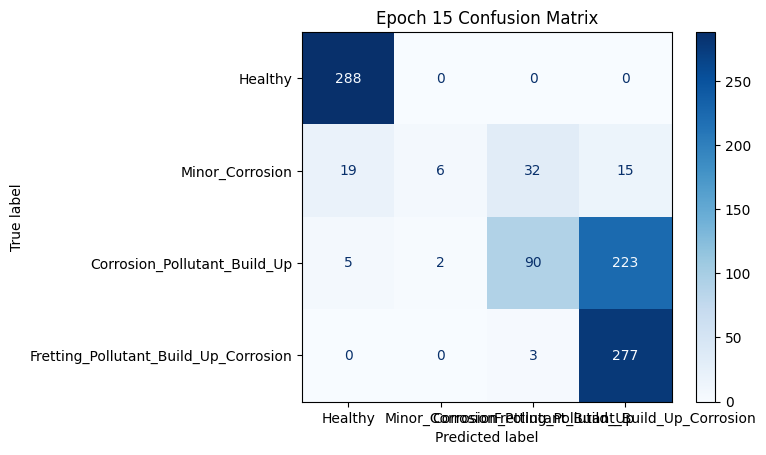


--- Epoch 16/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 16 Summary:
  - Time elapsed: 75.81 sec
  - Train Loss: 0.082288, Train Acc: 89.22%
  - Val Loss: 0.084310, Val Acc: 89.13%
  - Loss Gap (Val-Train)/Train: 2.46%
  - Ordinal Accuracy: 68.54%
  - Precision (macro): 0.7141
  - Recall (macro): 0.5833
  - F1 Score (macro): 0.5445
  -> No improvement for 1 epoch(s).


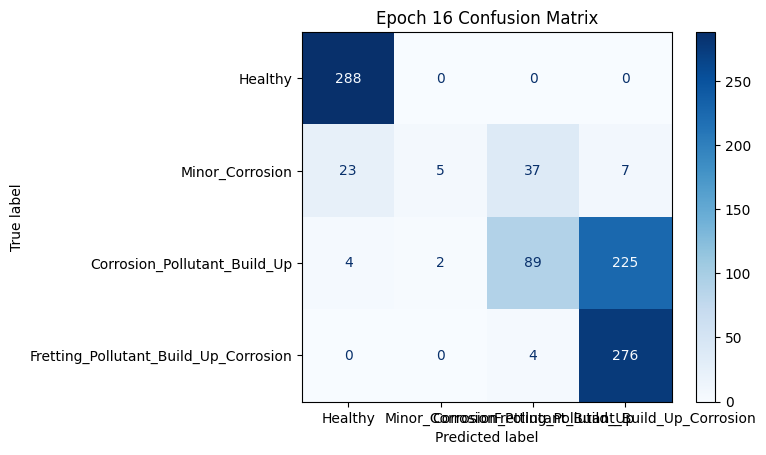


--- Epoch 17/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 17 Summary:
  - Time elapsed: 75.65 sec
  - Train Loss: 0.078627, Train Acc: 90.15%
  - Val Loss: 0.081730, Val Acc: 92.78%
  - Loss Gap (Val-Train)/Train: 3.95%
  - Ordinal Accuracy: 79.38%
  - Precision (macro): 0.7219
  - Recall (macro): 0.6588
  - F1 Score (macro): 0.6431
  -> No improvement for 2 epoch(s).


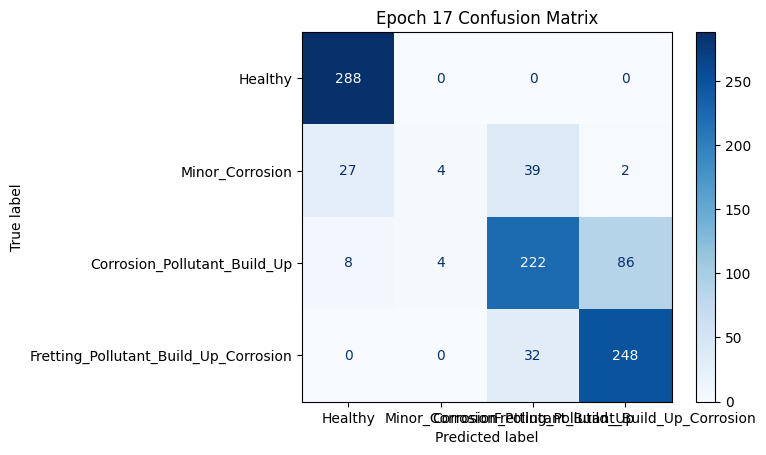


--- Epoch 18/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 18 Summary:
  - Time elapsed: 74.87 sec
  - Train Loss: 0.078048, Train Acc: 90.29%
  - Val Loss: 0.075614, Val Acc: 92.50%
  - Loss Gap (Val-Train)/Train: -3.12%
  - Ordinal Accuracy: 77.92%
  - Precision (macro): 0.7681
  - Recall (macro): 0.6581
  - F1 Score (macro): 0.6467
  -> Validation loss improved; model saved!


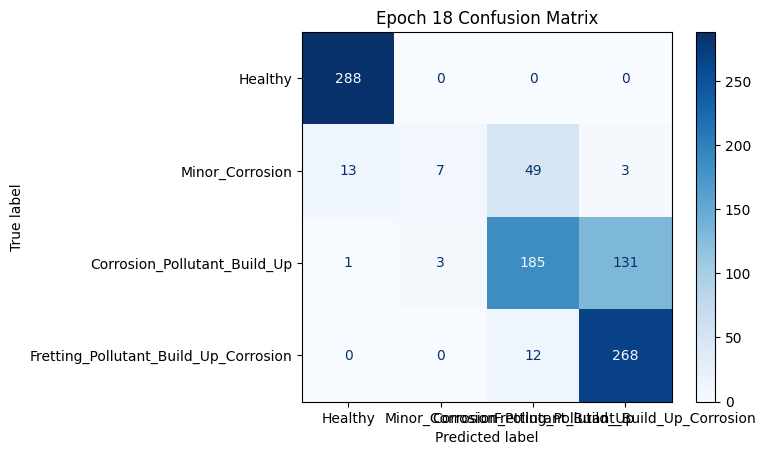


--- Epoch 19/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 19 Summary:
  - Time elapsed: 75.30 sec
  - Train Loss: 0.078707, Train Acc: 90.75%
  - Val Loss: 0.076838, Val Acc: 91.56%
  - Loss Gap (Val-Train)/Train: -2.37%
  - Ordinal Accuracy: 75.31%
  - Precision (macro): 0.5772
  - Recall (macro): 0.6198
  - F1 Score (macro): 0.5871
  -> No improvement for 1 epoch(s).


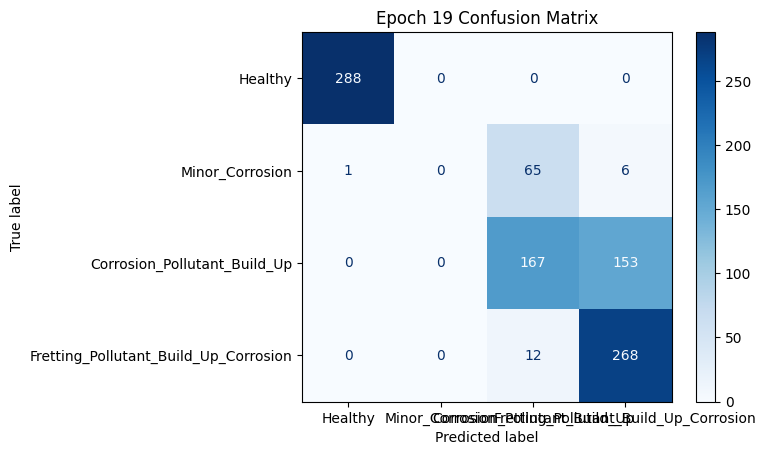


--- Epoch 20/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 20 Summary:
  - Time elapsed: 75.69 sec
  - Train Loss: 0.075182, Train Acc: 91.36%
  - Val Loss: 0.075055, Val Acc: 92.15%
  - Loss Gap (Val-Train)/Train: -0.17%
  - Ordinal Accuracy: 76.77%
  - Precision (macro): 0.8343
  - Recall (macro): 0.6624
  - F1 Score (macro): 0.6638
  -> Validation loss improved; model saved!


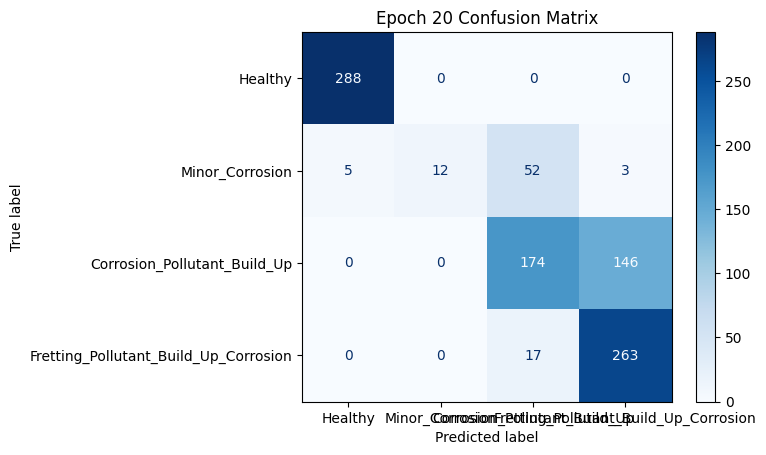


--- Epoch 21/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 21 Summary:
  - Time elapsed: 76.34 sec
  - Train Loss: 0.074240, Train Acc: 91.64%
  - Val Loss: 0.073782, Val Acc: 87.81%
  - Loss Gap (Val-Train)/Train: -0.62%
  - Ordinal Accuracy: 65.10%
  - Precision (macro): 0.7512
  - Recall (macro): 0.5466
  - F1 Score (macro): 0.4920
  -> Validation loss improved; model saved!


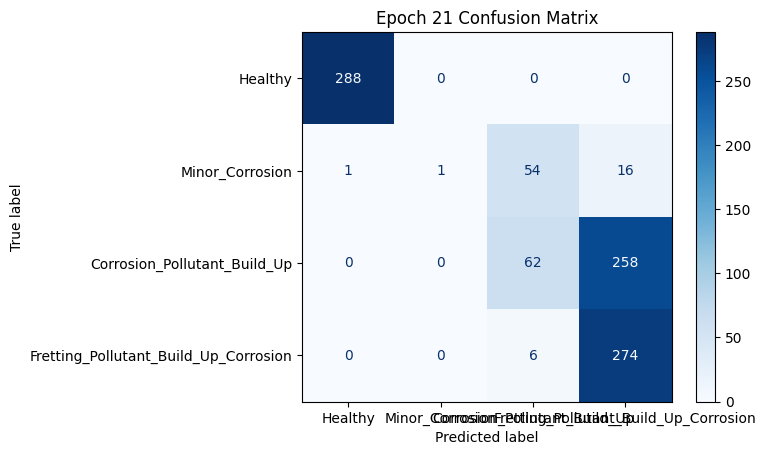


--- Epoch 22/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 22 Summary:
  - Time elapsed: 81.95 sec
  - Train Loss: 0.073381, Train Acc: 92.01%
  - Val Loss: 0.071640, Val Acc: 92.88%
  - Loss Gap (Val-Train)/Train: -2.37%
  - Ordinal Accuracy: 79.48%
  - Precision (macro): 0.7874
  - Recall (macro): 0.6587
  - F1 Score (macro): 0.6371
  -> Validation loss improved; model saved!


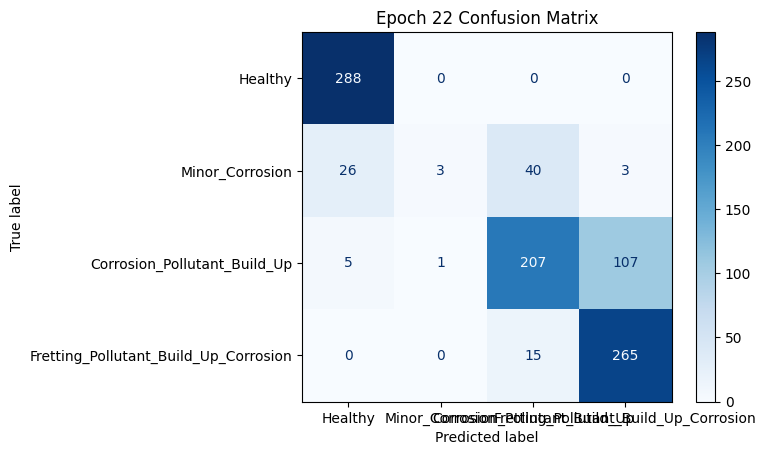


--- Epoch 23/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 23 Summary:
  - Time elapsed: 79.18 sec
  - Train Loss: 0.073042, Train Acc: 92.37%
  - Val Loss: 0.071053, Val Acc: 93.30%
  - Loss Gap (Val-Train)/Train: -2.72%
  - Ordinal Accuracy: 80.21%
  - Precision (macro): 0.8235
  - Recall (macro): 0.6730
  - F1 Score (macro): 0.6622
  -> Validation loss improved; model saved!


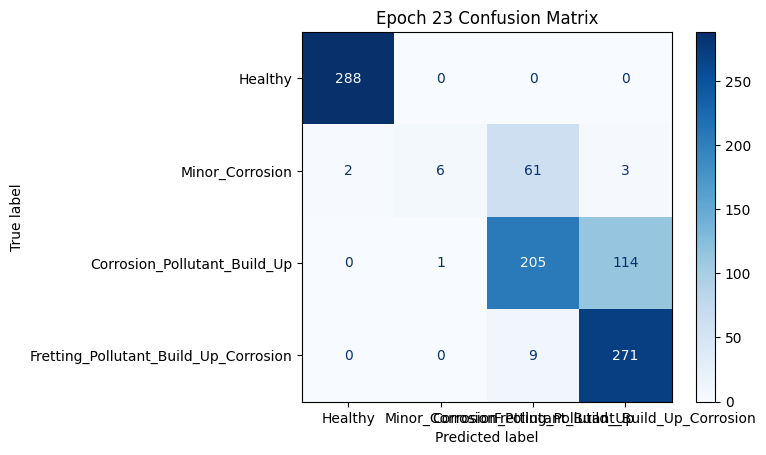


--- Epoch 24/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.
[Train] Batch 110/120 processed.
[Train] Batch 120/120 processed.
[Validation] Batch 10/30 processed.
[Validation] Batch 20/30 processed.
[Validation] Batch 30/30 processed.

Epoch 24 Summary:
  - Time elapsed: 77.70 sec
  - Train Loss: 0.071958, Train Acc: 92.74%
  - Val Loss: 0.071270, Val Acc: 93.58%
  - Loss Gap (Val-Train)/Train: -0.96%
  - Ordinal Accuracy: 81.25%
  - Precision (macro): 0.8104
  - Recall (macro): 0.6947
  - F1 Score (macro): 0.6981
  -> No improvement for 1 epoch(s).


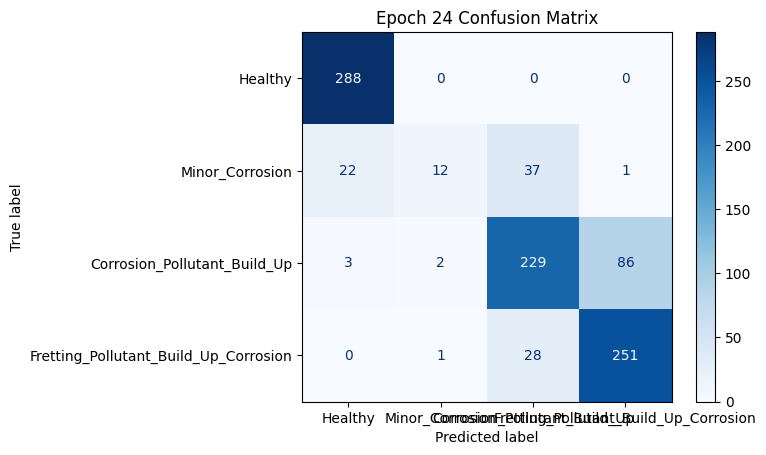


--- Epoch 25/100 ---
[Train] Batch 10/120 processed.
[Train] Batch 20/120 processed.
[Train] Batch 30/120 processed.
[Train] Batch 40/120 processed.
[Train] Batch 50/120 processed.
[Train] Batch 60/120 processed.
[Train] Batch 70/120 processed.
[Train] Batch 80/120 processed.
[Train] Batch 90/120 processed.
[Train] Batch 100/120 processed.


KeyboardInterrupt: 

In [ ]:
# Instantiate CORAL ResNet-50
coral_model = CORALResNet50(num_classes=len(CLASSES), dropout_rate=0.4)
# Assume coral_loss_fn is defined (a loss function appropriate for ordinal CORAL outputs)
trained_model = train_evaluate_coral_model(
    coral_model,
    train_loader_original,
    test_loader_original,    # using test_loader as validation in this example
    coral_loss_fn,
    device,
    epochs=100,
    patience=10,
    lr=3e-4,
    save_path=SAVE_PATH
)

In [ ]:
#torch.save(coral_model.state_dict(), SAVE_PATH)
print("Model exists:", os.path.exists(SAVE_PATH))


In [ ]:
# Final Evaluation on test_loader_original
trained_model.eval()
total_val_samples = 0
running_val_loss = 0.0
all_labels = []
all_preds = []
with torch.no_grad():
    for images, labels in test_loader_original:
        images, labels = images.to(device), labels.to(device)
        outputs = trained_model(images)
        loss = coral_loss_fn(outputs, labels)
        running_val_loss += loss.item() * images.size(0)
        # For CORAL: ordinal prediction = number of thresholds where logit > 0
        preds = (outputs > 0).sum(dim=1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        total_val_samples += labels.size(0)
avg_loss = running_val_loss / total_val_samples

# Compute additional metrics using sklearn
val_accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
f1 = f1_score(all_labels, all_preds, average='macro')

# Print detailed validation metrics
mode = "Validation"
print(f'\n{mode} Loss: {avg_loss:.4f}')
print(f'{mode} Ordinal Accuracy: {val_accuracy:.2f}%')
print(f'{mode} Precision (macro): {precision:.4f}')
print(f'{mode} Recall (macro): {recall:.4f}')
print(f'{mode} F1 Score (macro): {f1:.4f}')

NameError: name 'trained_model' is not defined